# 1. Define QUBO matrix

In [1]:
import sys
import numpy as np
from scipy.spatial.distance import cdist

sys.path.append("..")
from src.qubo_windfarm_layout.model import get_farm_area, get_mask, build_qubo_from_wake_matrix_optimized, build_wake_loss_matrix_optimized
from src.qubo_windfarm_layout.visualization import plot_selected_layout

In [2]:
# Variables
GRID_RESOLUTION = 200 # m
MIN_DISTANCE = 396  # 2 * 198 m

# Get candidates
polygons, farm_area = get_farm_area()
X, Y, mask = get_mask(farm_area=farm_area, grid_resolution=GRID_RESOLUTION)

candidate_locations = np.column_stack([
    X[mask],
    Y[mask],
])

print(f"Filtered candidates shape {candidate_locations.shape}")

# Invalid pairs constraint


distances = cdist(
    candidate_locations,
    candidate_locations
)

invalid_pairs = np.argwhere(
    (distances < MIN_DISTANCE)
    & (distances > 0)
)

invalid_pairs = np.argwhere(
    np.triu(
        (distances < MIN_DISTANCE)
        & (distances > 0),
        k=1
    )
)

# Matrix definition
wake_loss_matrix, A0 = build_wake_loss_matrix_optimized(
    candidate_locations,
    grid_resolution=GRID_RESOLUTION,
)

Q, offset = build_qubo_from_wake_matrix_optimized(
    wake_loss_matrix,
    invalid_pairs,
    A0,
    n_turbines=81,
)

Filtered candidates shape (905, 2)
Numero candidate locations: 905
Numero coppie totali: 409,060
Numero displacement unici: 3,690


# 2. Solvers

## 2.1 OR Tools 

In [4]:
from ortools.sat.python import cp_model


def solve_wflo_ortools(
    wake_loss_matrix,
    invalid_pairs,
    n_turbines=81,
    time_limit_s=300,
    num_workers=8,
    coefficient_scale=1000,
    min_wake_loss=0.0,
):
    """
    Risolve il WFLO con OR-Tools usando:

        min sum_{i<j} L_ij z_i z_j

    subject to:

        sum_i z_i = n_turbines

        z_i + z_j <= 1
        per ogni coppia che viola la distanza minima.
    """

    L = np.asarray(
        wake_loss_matrix,
        dtype=float,
    )

    n = L.shape[0]

    model = cp_model.CpModel()

    z = [
        model.NewBoolVar(f"z_{i}")
        for i in range(n)
    ]

    # ==========================================
    # Vincolo: esattamente 81 turbine
    # ==========================================

    model.Add(
        sum(z) == n_turbines
    )

    # ==========================================
    # Vincolo: distanza minima
    # ==========================================

    for i, j in invalid_pairs:

        model.Add(
            z[int(i)] + z[int(j)] <= 1
        )

    # ==========================================
    # Wake objective
    # ==========================================

    objective_terms = []

    for i in range(n):

        for j in range(i + 1, n):

            loss = L[i, j]

            # Eventuale pruning delle interazioni
            # trascurabili.
            if loss <= min_wake_loss:
                continue

            coeff = int(
                round(
                    loss * coefficient_scale
                )
            )

            if coeff == 0:
                continue

            # y_ij = z_i AND z_j
            y_ij = model.NewBoolVar(
                f"y_{i}_{j}"
            )

            model.AddMultiplicationEquality(
                y_ij,
                [z[i], z[j]],
            )

            objective_terms.append(
                coeff * y_ij
            )

    model.Minimize(
        sum(objective_terms)
    )

    # ==========================================
    # Solve
    # ==========================================

    solver = cp_model.CpSolver()

    solver.parameters.max_time_in_seconds = (
        time_limit_s
    )

    solver.parameters.num_search_workers = (
        num_workers
    )

    status = solver.Solve(model)

    print(
        "Status:",
        solver.StatusName(status),
    )

    if status not in (
        cp_model.OPTIMAL,
        cp_model.FEASIBLE,
    ):
        raise RuntimeError(
            "Nessuna soluzione trovata."
        )

    solution = np.array(
        [
            solver.Value(var)
            for var in z
        ],
        dtype=int,
    )

    wake_objective = (
        solver.ObjectiveValue()
        / coefficient_scale
    )

    print(
        f"Turbine selezionate: "
        f"{solution.sum()}"
    )

    print(
        f"Pairwise wake loss: "
        f"{wake_objective}"
    )

    return solution, solver

In [5]:
z_solution, solver = solve_wflo_ortools(
    wake_loss_matrix=wake_loss_matrix,
    invalid_pairs=invalid_pairs,
    n_turbines=81,
    time_limit_s=60,
    num_workers=8,
)

selected_locations = candidate_locations[
    z_solution.astype(bool)
]

Status: FEASIBLE
Turbine selezionate: 81
Pairwise wake loss: 1084414.288


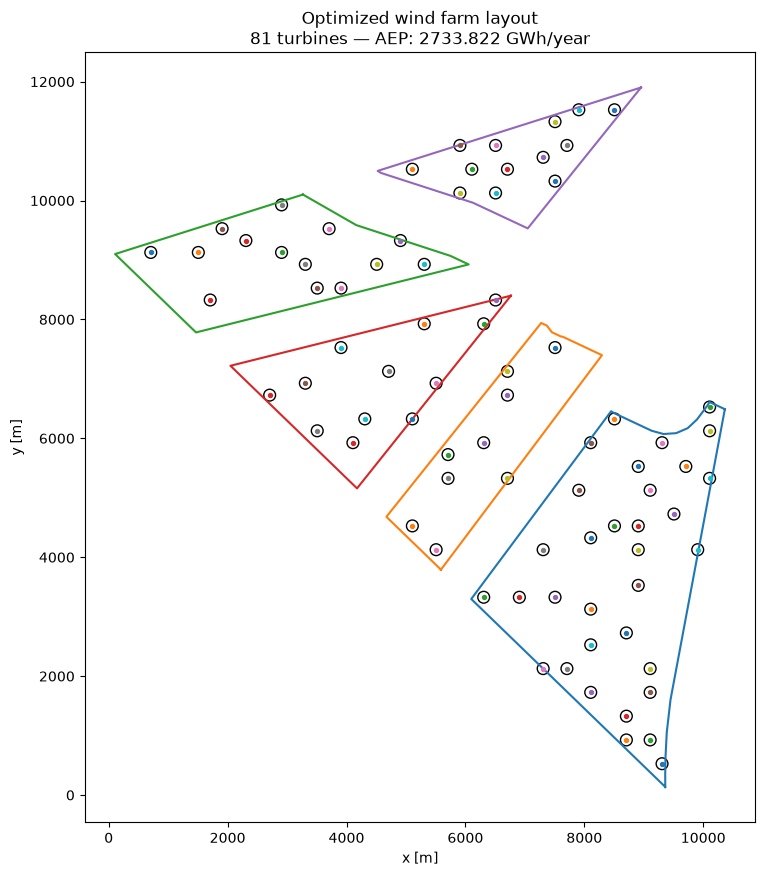

In [6]:
plot_selected_layout(selected_locations=selected_locations)

In [11]:
from pathlib import Path
import numpy as np
import yaml


def save_benchmark_layout(
    selected_locations,
    solver_name,
    output_dir,
    filename=None,
    grid_resolution=None,
):
    """
    Salva un layout nello stesso schema utilizzato dai file
    del benchmark Thomas et al.

    Il file risultante è compatibile con getTurbLocYAML()
    e calculate_aep() del provided_model.py.
    """

    selected_locations = np.asarray(
        selected_locations,
        dtype=float,
    )

    if selected_locations.ndim != 2 or selected_locations.shape[1] != 2:
        raise ValueError(
            "selected_locations deve avere shape (N, 2)"
        )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if filename is None:
        filename = f"{solver_name}.yaml"

    output_path = output_dir / filename

    data = {
        "title": f"IEA Wind Task 37 case study 4 - {solver_name}",
        "description": (
            f"Layout generated using {solver_name}"
        ),

        # Metadata nostri.
        # Il parser originale li ignora.
        "metadata": {
            "solver": solver_name,
            "grid_resolution": grid_resolution,
            "n_turbines": len(selected_locations),
        },

        "definitions": {

            "wind_plant": {
                "type": "object",
                "description": "wind plant design",
                "properties": {
                    "turbine": {
                        "type": "array",
                        "items": [
                            {
                                "$ref": "iea37-10mw.yaml"
                            }
                        ],
                    }
                },
            },

            "position": {
                "description": (
                    "Turbine positions in Cartesian coordinates"
                ),
                "units": "m",
                "items": selected_locations.tolist(),
            },

            "plant_energy": {
                "description": "energy production data",
                "properties": {

                    "wake_model": {
                        "description": "wake model used to calculate AEP",
                        "items": [
                            {
                                "$ref": "iea37-aepcalc.py"
                            }
                        ],
                    },

                    "wind_resource": {
                        "description": (
                            "wind resource used to calculate AEP"
                        ),
                        "properties": {
                            "items": [
                                {
                                    "$ref": "iea37-windrose-cs4.yaml"
                                }
                            ]
                        },
                    },

                    # Volutamente non inseriamo l'AEP:
                    # verrà ricalcolata nel notebook di evaluation.
                },
            },
        },
    }

    with open(output_path, "w") as f:
        yaml.safe_dump(
            data,
            f,
            sort_keys=False,
        )

    print(f"Layout saved to: {output_path}")

    return output_path

OUTPUT_DIR = "results/layouts"

save_benchmark_layout(
    selected_locations=selected_locations,
    solver_name="ortools",
    output_dir=OUTPUT_DIR,
    filename="ortools_200m.yaml",
    grid_resolution=200,
)

Layout saved to: results/layouts/ortools_200m.yaml


PosixPath('results/layouts/ortools_200m.yaml')

In [7]:
# TODO
# Capire se usare base.yaml come starting point (warmstart) può creare dei vantaggi per i solutori quantum